<a href="https://colab.research.google.com/github/renealejrdzcst-spec/IA-Verano-2026-Ren-Rdz/blob/main/Assignments/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF2 - Data Processing

**Authors:**
- Eugenio Espronceda Acosta
- René Alejandro Rodríguez Castañeda
- Manuel Alejandro Juárez Grimaldo

**Student IDs:**
- 2096538
- 2019068
- 2115290

**Class Schedule: V4**

**Group** 001

Part 1: Data Loading and exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [4]:
df = pd.read_csv("diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns:
    print(f"{col}: {(df[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In this part, the required libraries are imported, and the diabetes.csv dataset is loaded into a Pandas DataFrame. The first rows are displayed to verify the data, while missing and invalid zero values are identified. Finally, descriptive statistics and Matplotlib visualizations are used to explore the data distribution and better understand the dataset before the preprocessing stage.

Part 2: Data Cleaning and Normalization

In [11]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    median = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median)

print("Zero values replaced successfully.")

scaler = MinMaxScaler()

numeric_columns = df.drop('Outcome', axis=1).columns

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("\nNormalized Data.")
print(df.head())

Zero values replaced successfully.

Normalized Data.
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.643357       0.456522       0.296703  0.132371  0.312115   
1     0.058824  0.202797       0.391304       0.230769  0.132371  0.168378   
2     0.470588  0.888112       0.369565       0.230769  0.132371  0.100616   
3     0.058824  0.230769       0.391304       0.164835  0.095066  0.199179   
4     0.000000  0.566434       0.108696       0.296703  0.184116  0.507187   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.234415  0.483333        1  
1                  0.116567  0.166667        0  
2                  0.253629  0.183333        1  
3                  0.038002  0.000000        0  
4                  0.943638  0.200000        1  


In this part, zero values in the columns Glucose, BloodPressure, SkinThickness, Insulin, and BMI were replaced with the median of each column because these values are considered invalid. After cleaning the data, Min-Max Scaling was applied to normalize all numerical features to a range between 0 and 1. This makes the data more consistent and suitable for analysis.

Part 3: Data Visualization

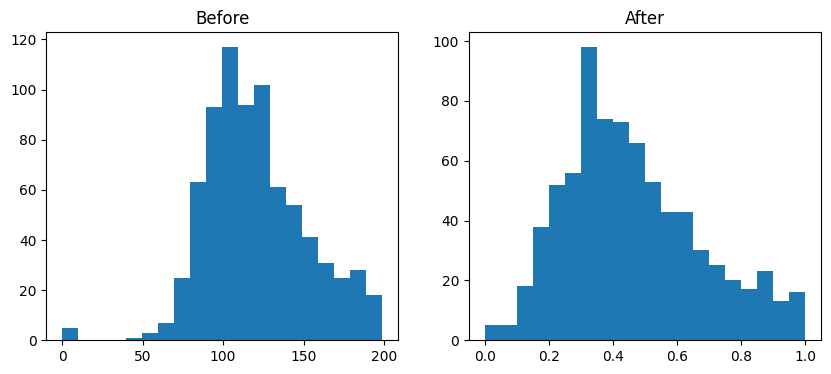

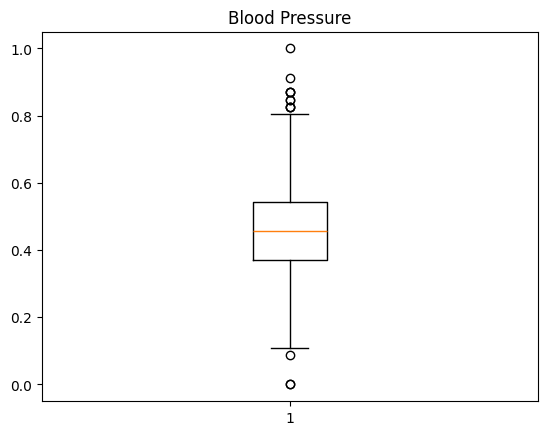

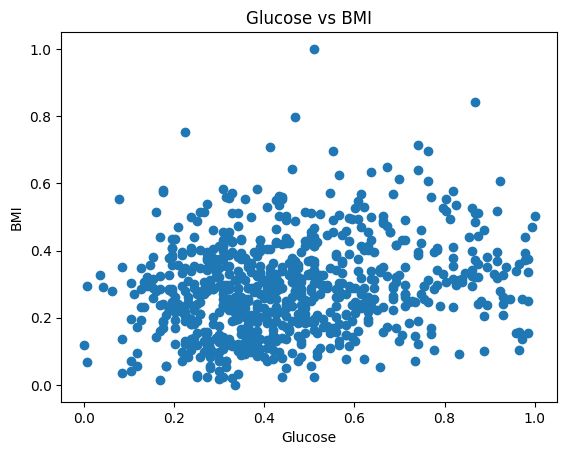

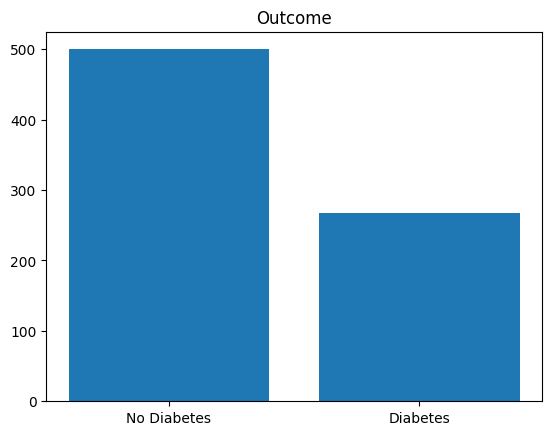

In [13]:
original_df = pd.read_csv("diabetes.csv")

# 1. Histogram
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(original_df["Glucose"], bins=20)
plt.title("Before")

plt.subplot(1,2,2)
plt.hist(df["Glucose"], bins=20)
plt.title("After")

plt.show()

# 2. Blood pressure boxplot
plt.boxplot(df["BloodPressure"])
plt.title("Blood Pressure")
plt.show()

# 3. Scatter Plot Glucose vs BMI
plt.scatter(df["Glucose"], df["BMI"])
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

# 4. Outcome bar chart
counts = original_df["Outcome"].value_counts()

plt.bar(["No Diabetes", "Diabetes"], counts)
plt.title("Outcome")
plt.show()

In this part, different charts were created to better understand the dataset. A histogram was used to compare glucose values before and after normalization. A boxplot was used to identify outliers in blood pressure. A scatter plot was created to observe the relationship between glucose and BMI. Finally, a bar chart showed the number of patients with and without diabetes based on the Outcome variable.

Part 4 - Questions

1. What impact do missing values have on data analysis?

Missing values can affect the analysis because they can produce incorrect or biased results, if they are not handled correctly before training the model

2. How can we detect and handle outliers in biomedical datasets?

Outliers can be detected using boxplots descriptive statistics or methods like the interquartile range (IQR), depending on the case they can be removed corrected or replaced

3. What are some common causes of missing or incorrect data in biomedical studies?

Some common causes are human mistakes during data collection, equipment failures incomplete patient records or missing laboratory tests

4. How does normalizing data improve the performance of Machine Learning models?

Normalization puts the numerical values on a similar scale so that variables with larger values do not have more influence than the others, this usually improves the model performance

5. Why is visualizing data an important step before applying Machine Learning models?

Data visualization helps us understand the dataset better it also makes it easier to find patterns trends outliers or possible errors before training the model

6. Why is preprocessing critical when working with medical datasets?

Preprocessing improves the quality of the data by fixing inconsistencies handling missing values and preparing the dataset for analysis this helps build more reliable Machine Learning models

7. What ethical concerns should be considered when handling patient data?

Patient information should always remain private and confidential, researchers should protect personal data use it responsibly and follow ethical guidelines when working with medical information